# Final Project Students Performance Dataset
We used Claude Sonnet 4.6 & Opus 4.7 to help generate responses.

---

## Introduction

Academic performance is a multi-dimensional outcome shaped by cognitive ability, prior knowledge, motivation, and **socioeconomic context**. Understanding which socioeconomic factors are predictive of student outcomes is critical for schools, policymakers, and intervention designers who must allocate limited resources toward students most at risk of underperforming.


## Pre-processing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score
)

from google.colab import drive
drive.mount('/content/drive')

path_to_data_folder = '/content/drive/MyDrive/DSCI 303/'

import os
os.chdir('/content/drive/MyDrive/DSCI 303')

df = pd.read_csv('StudentsPerformance.csv')
print('Shape:', df.shape)
df.head()
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1000, 8)


In [3]:
# Unified academic plotting style
# Apply once at the top of the notebook so every chart uses the same look.
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.family':       'serif',
    'font.size':          10,
    'axes.titlesize':     11,
    'axes.titleweight':   'normal',
    'axes.labelsize':     10,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'figure.dpi':         110,
    'savefig.dpi':        300,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linewidth':     0.5,
    'axes.axisbelow':     True,
    'lines.linewidth':    1.5,
})

# Single neutral palette used across every chart
GRAY    = '#4a4a4a'   # primary
LIGHT   = '#a8a8a8'   # secondary
ACCENT  = '#3a5f8a'   # academic muted blue, used for emphasis
DARK    = '#1f1f1f'   # text/axis lines
SEQ_CMAP = 'Greys'
HEAT_CMAP = 'Blues'


In [4]:
# Save paper figures to /content/paper_figures/
import os
os.makedirs('/content/paper_figures', exist_ok=True)
print('Paper figures will be saved to: /content/paper_figures/')

Paper figures will be saved to: /content/paper_figures/


In [5]:
# Rename columns for easier use
df.columns = ['gender', 'race_ethnicity', 'parental_education', 'lunch',
              'test_prep', 'math_score', 'reading_score', 'writing_score']

print('Missing values per column:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)
print('\nDescriptive statistics:')
df[['math_score', 'reading_score', 'writing_score']].describe()

Missing values per column:
gender                0
race_ethnicity        0
parental_education    0
lunch                 0
test_prep             0
math_score            0
reading_score         0
writing_score         0
dtype: int64

Data types:
gender                object
race_ethnicity        object
parental_education    object
lunch                 object
test_prep             object
math_score             int64
reading_score          int64
writing_score          int64
dtype: object

Descriptive statistics:


,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
# Check for duplicates and score ranges
print('Duplicate rows:', df.duplicated().sum())

for col in ['math_score', 'reading_score', 'writing_score']:
    print(f'{col}: min={df[col].min()}, max={df[col].max()}')

Duplicate rows: 0
math_score: min=0, max=100
reading_score: min=17, max=100
writing_score: min=10, max=100


In [7]:
# Check value counts for categorical variables
for col in ['gender', 'race_ethnicity', 'parental_education', 'lunch', 'test_prep']:
    print(f'{col}:')
    print(df[col].value_counts())
    print()

gender:
gender
female    518
male      482
Name: count, dtype: int64

race_ethnicity:
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental_education:
parental_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test_prep:
test_prep
none         642
completed    358
Name: count, dtype: int64



## Feature Engineering

In [8]:
# Create average and total scores as target variables
df['avg_score'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

# Binary target: high performer = above 75th percentile of avg_score
threshold = df['avg_score'].quantile(0.75)
df['high_performer'] = (df['avg_score'] >= threshold).astype(int)
print('High performer threshold (75th percentile):', round(threshold, 2))
print('High performers:', df['high_performer'].sum())
print('Non-high performers:', (df['high_performer'] == 0).sum())

High performer threshold (75th percentile): 77.67
High performers: 254
Non-high performers: 746


In [9]:
# Encode parental education as ordinal — reflects increasing education level
edu_order = {
    'some high school': 0,
    'high school': 1,
    'some college': 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}
df['parental_edu_encoded'] = df['parental_education'].map(edu_order)
print('Parental education encoding:')
print(df[['parental_education', 'parental_edu_encoded']].drop_duplicates().sort_values('parental_edu_encoded'))

Parental education encoding:
    parental_education  parental_edu_encoded
15    some high school                     0
8          high school                     1
1         some college                     2
3   associate's degree                     3
0    bachelor's degree                     4
2      master's degree                     5


In [10]:
# One-hot encode remaining categorical features
df_encoded = pd.get_dummies(df, columns=['gender', 'race_ethnicity', 'lunch', 'test_prep'],
                             drop_first=False)
print('Encoded dataframe shape:', df_encoded.shape)
print('Columns:', list(df_encoded.columns))

Encoded dataframe shape: (1000, 19)
Columns: ['parental_education', 'math_score', 'reading_score', 'writing_score', 'avg_score', 'total_score', 'high_performer', 'parental_edu_encoded', 'gender_female', 'gender_male', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group D', 'race_ethnicity_group E', 'lunch_free/reduced', 'lunch_standard', 'test_prep_completed', 'test_prep_none']


## EDA

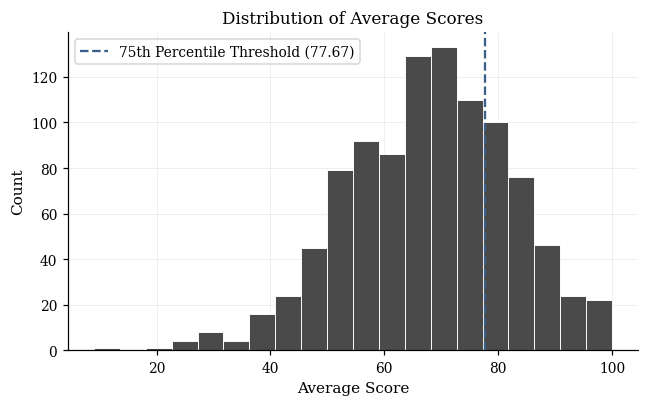

High-performer threshold: 77.67


In [11]:
# Distribution of Average Score (with high-performer threshold)
threshold = df['avg_score'].quantile(0.75)

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.hist(df['avg_score'], bins=20, color=GRAY, edgecolor='white', linewidth=0.6)
ax.axvline(threshold, color=ACCENT, linestyle='--', linewidth=1.5,
           label=f'75th Percentile Threshold ({threshold:.2f})')
ax.set_xlabel('Average Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Average Scores')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('/content/paper_figures/score_distribution_main.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'High-performer threshold: {threshold:.2f}')

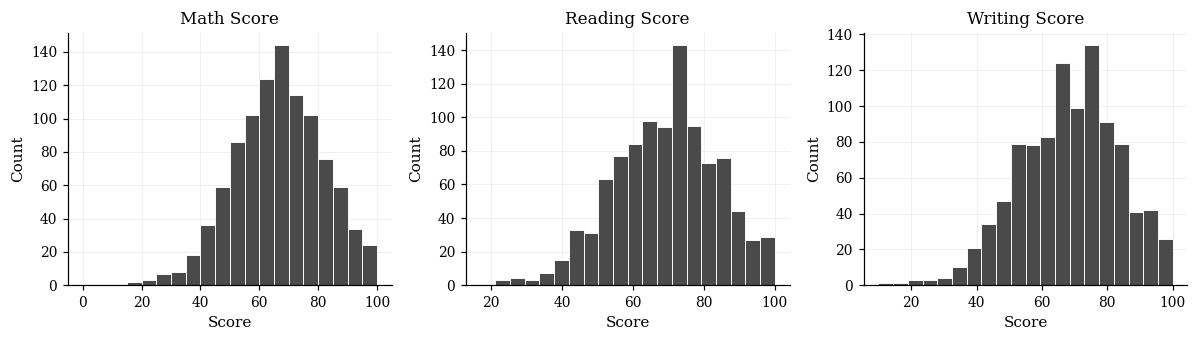

In [12]:
# Score distributions
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, ['math_score', 'reading_score', 'writing_score']):
    ax.hist(df[col], bins=20, color=GRAY, edgecolor='white', linewidth=0.6)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

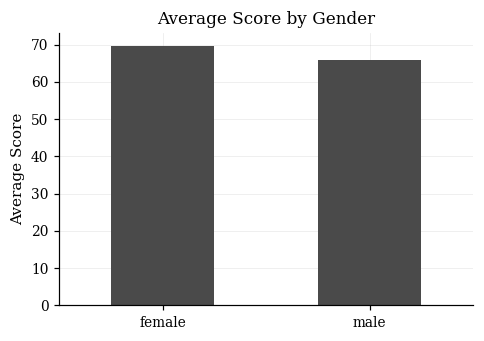

In [13]:
# Average score by gender
fig, ax = plt.subplots(figsize=(4.5, 3.2))
df.groupby('gender')['avg_score'].mean().plot(kind='bar', color=GRAY, ax=ax, width=0.5)
ax.set_title('Average Score by Gender')
ax.set_ylabel('Average Score')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

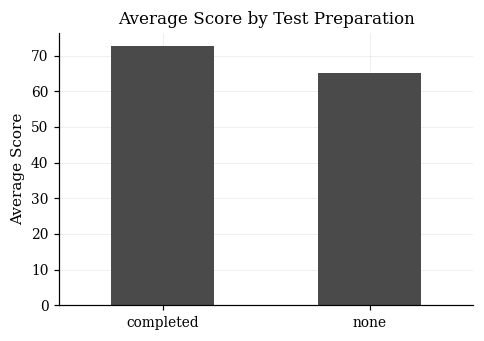

In [14]:
# Average score by test preparation course
fig, ax = plt.subplots(figsize=(4.5, 3.2))
df.groupby('test_prep')['avg_score'].mean().plot(kind='bar', color=GRAY, ax=ax, width=0.5)
ax.set_title('Average Score by Test Preparation')
ax.set_ylabel('Average Score')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

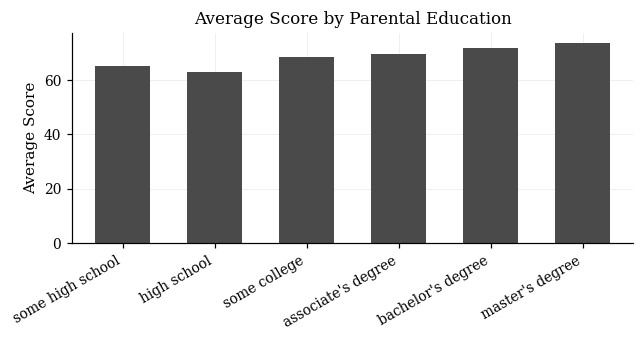

In [15]:
# Average score by parental education level
edu_avg = df.groupby('parental_education')['avg_score'].mean().reindex(
    ['some high school', 'high school', 'some college',
     "associate's degree", "bachelor's degree", "master's degree"]
)
fig, ax = plt.subplots(figsize=(6, 3.2))
edu_avg.plot(kind='bar', color=GRAY, ax=ax, width=0.6)
ax.set_title('Average Score by Parental Education')
ax.set_ylabel('Average Score')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

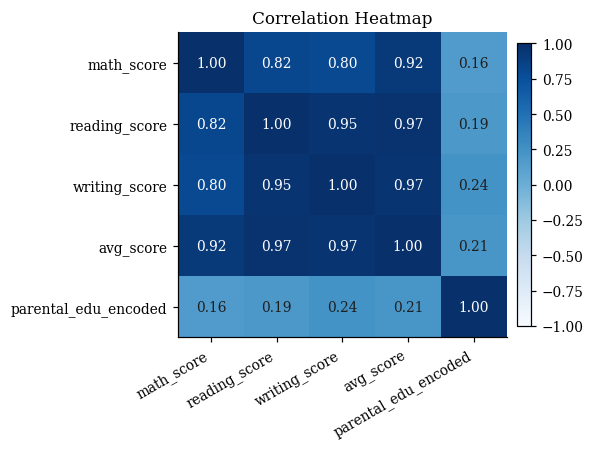

In [16]:
# Correlation heatmap (numeric columns)
numeric_cols = ['math_score', 'reading_score', 'writing_score',
                'avg_score', 'parental_edu_encoded']
corr = df_encoded[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.2))
im = ax.imshow(corr.values, cmap=HEAT_CMAP, vmin=-1, vmax=1, aspect='auto')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v > 0.5 else DARK, fontsize=9)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=30, ha='right')
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
ax.grid(False)
ax.set_title('Correlation Heatmap')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
plt.tight_layout()
plt.show()

Compounding Disadvantage Heatmap

Shows avg_score for every combination of lunch status × test_prep × parental education tier. Reveals whether disadvantages compound on each other.

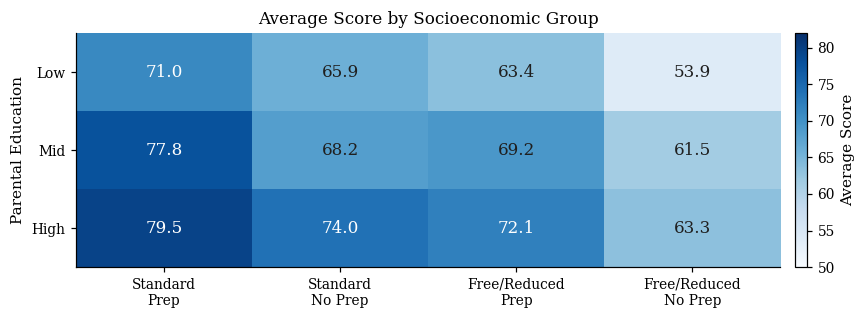

In [17]:
# Bin parental education into 3 tiers
df['edu_tier'] = df['parental_edu_encoded'].map({
    0: 'Low', 1: 'Low',
    2: 'Mid', 3: 'Mid',
    4: 'High', 5: 'High'
})
tier_order = ['Low', 'Mid', 'High']

df['group_label'] = df['lunch'] + ' / ' + df['test_prep']
group_order = ['standard / completed', 'standard / none',
               'free/reduced / completed', 'free/reduced / none']

pivot = (df.groupby(['edu_tier', 'group_label'])['avg_score']
           .mean()
           .unstack('group_label')
           .reindex(index=tier_order, columns=group_order))

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(pivot.values, cmap=HEAT_CMAP, aspect='auto', vmin=50, vmax=82)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        text_color = 'white' if val > 70 else DARK
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=11, color=text_color)

ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(['Standard\nPrep', 'Standard\nNo Prep',
                    'Free/Reduced\nPrep', 'Free/Reduced\nNo Prep'])
ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels(tier_order)
ax.set_ylabel('Parental Education')
ax.grid(False)
ax.set_title('Average Score by Socioeconomic Group')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Average Score')
plt.tight_layout()
plt.savefig('/content/paper_figures/compounding_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Selection

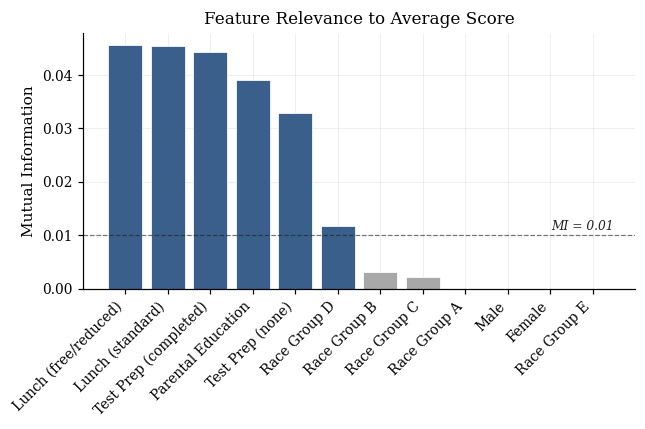

Selected features (MI > 0.01): ['lunch_free/reduced', 'lunch_standard', 'test_prep_completed', 'parental_edu_encoded', 'test_prep_none', 'race_ethnicity_group D']


In [18]:
# Build feature matrix from DEMOGRAPHIC features only (no score columns)
demographic_cols = [c for c in df_encoded.columns
                    if c not in ['math_score', 'reading_score', 'writing_score',
                                 'avg_score', 'total_score', 'high_performer',
                                 'parental_education']]
X_all = df_encoded[demographic_cols]

# Mutual information vs avg_score
mi_scores = mutual_info_regression(X_all, df_encoded['avg_score'], random_state=0)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

# Clean up variable names for display
label_map = {
    'lunch_free/reduced':    'Lunch (free/reduced)',
    'lunch_standard':        'Lunch (standard)',
    'test_prep_completed':   'Test Prep (completed)',
    'test_prep_none':        'Test Prep (none)',
    'parental_edu_encoded':  'Parental Education',
    'race_ethnicity_group A':'Race Group A',
    'race_ethnicity_group B':'Race Group B',
    'race_ethnicity_group C':'Race Group C',
    'race_ethnicity_group D':'Race Group D',
    'race_ethnicity_group E':'Race Group E',
    'gender_female':         'Female',
    'gender_male':           'Male',
}
mi_series_display = mi_series.rename(index=label_map)

# Color: emphasize features above the 0.01 threshold
colors = [ACCENT if v > 0.01 else LIGHT for v in mi_series_display.values]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(mi_series_display)), mi_series_display.values,
       color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.01, color=DARK, linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(len(mi_series_display) - 0.5, 0.011, 'MI = 0.01',
        ha='right', fontsize=8, style='italic', color=DARK)

ax.set_xticks(range(len(mi_series_display)))
ax.set_xticklabels(mi_series_display.index, rotation=45, ha='right')
ax.set_ylabel('Mutual Information')
ax.set_title('Feature Relevance to Average Score')
plt.tight_layout()
plt.savefig('/content/paper_figures/mi_scores.png', dpi=300, bbox_inches='tight')
plt.show()

# Select features with MI > 0.01 (using original column names for modeling)
selected_features = mi_series[mi_series > 0.01].index.tolist()
print('Selected features (MI > 0.01):', selected_features)

In [19]:
# Scale selected features
scaler = StandardScaler()
X_selected = df_encoded[selected_features]
X_selected_scaled = scaler.fit_transform(X_selected)

print('Feature matrix shape:', X_selected_scaled.shape)
print('Features used:', selected_features)

Feature matrix shape: (1000, 6)
Features used: ['lunch_free/reduced', 'lunch_standard', 'test_prep_completed', 'parental_edu_encoded', 'test_prep_none', 'race_ethnicity_group D']


## t-SNE Visualization

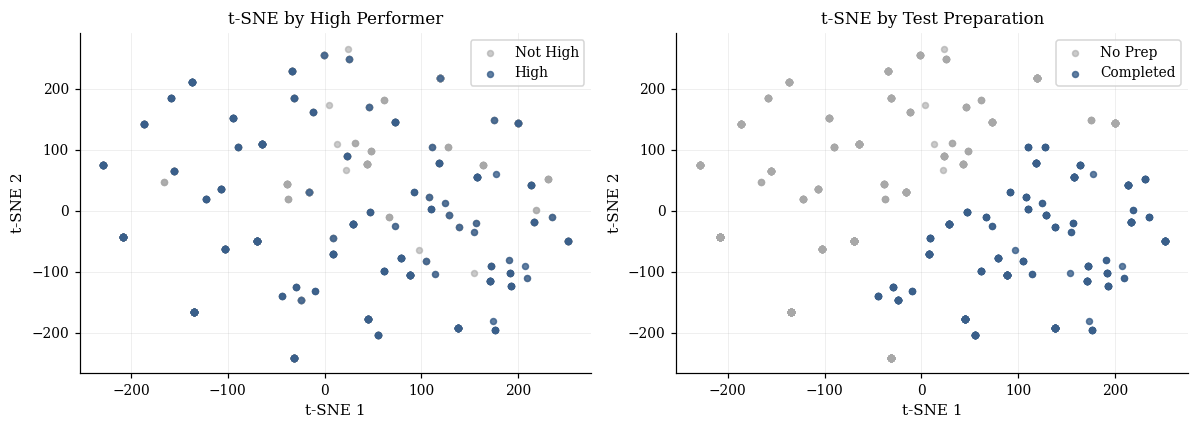

In [20]:
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
X_tsne = tsne.fit_transform(X_selected_scaled)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Colored by high_performer (binary -> two-tone gray)
hp = df_encoded['high_performer'].values
axes[0].scatter(X_tsne[hp == 0, 0], X_tsne[hp == 0, 1],
                c=LIGHT, alpha=0.6, s=15, label='Not High')
axes[0].scatter(X_tsne[hp == 1, 0], X_tsne[hp == 1, 1],
                c=ACCENT, alpha=0.8, s=15, label='High')
axes[0].set_title('t-SNE by High Performer')
axes[0].legend(loc='best', frameon=True)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

# Colored by test prep
test_col = 'test_prep_completed' if 'test_prep_completed' in df_encoded.columns else 'test_prep_none'
tp = df_encoded[test_col].values
axes[1].scatter(X_tsne[tp == 0, 0], X_tsne[tp == 0, 1],
                c=LIGHT, alpha=0.6, s=15, label='No Prep')
axes[1].scatter(X_tsne[tp == 1, 0], X_tsne[tp == 1, 1],
                c=ACCENT, alpha=0.8, s=15, label='Completed')
axes[1].set_title('t-SNE by Test Preparation')
axes[1].legend(loc='best', frameon=True)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

## Models

> **Feature sets used:**
> - **Top-5 MI features** (`X_selected_scaled`): the 5 demographic features with MI > 0.01 — used for apples-to-apples comparison.
> - **All demographic features** (`X_all_scaled`): all one-hot + ordinal demographic columns — gives models the best possible shot without using any score columns.
>
> No score columns (`math_score`, `reading_score`, `writing_score`, `avg_score`, `total_score`) are ever used as predictors.

In [21]:
# Feature set 1: top-5 MI-selected features (already built above)
# X_selected_scaled — 5 features

# Feature set 2: ALL demographic features (give models the best shot)
scaler2 = StandardScaler()
X_all_scaled = scaler2.fit_transform(X_all)

print('Top-5 MI features:', selected_features)
print('All demographic features:', list(X_all.columns))
print()
print('X_selected_scaled shape:', X_selected_scaled.shape)
print('X_all_scaled shape:     ', X_all_scaled.shape)

Top-5 MI features: ['lunch_free/reduced', 'lunch_standard', 'test_prep_completed', 'parental_edu_encoded', 'test_prep_none', 'race_ethnicity_group D']
All demographic features: ['parental_edu_encoded', 'gender_female', 'gender_male', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group D', 'race_ethnicity_group E', 'lunch_free/reduced', 'lunch_standard', 'test_prep_completed', 'test_prep_none']

X_selected_scaled shape: (1000, 6)
X_all_scaled shape:      (1000, 12)


In [22]:
# Use all demographic features as primary feature set
X_train_all, X_test_all, y_train_bin, y_test_bin = train_test_split(
    X_all_scaled, df_encoded['high_performer'], test_size=0.2, random_state=0
)
_, _, y_train_cont, y_test_cont = train_test_split(
    X_all_scaled, df_encoded['avg_score'], test_size=0.2, random_state=0
)

# Also split top-5 features (same indices, same random_state)
X_train_sel, X_test_sel, _, _ = train_test_split(
    X_selected_scaled, df_encoded['high_performer'], test_size=0.2, random_state=0
)

print('Train size:', X_train_all.shape[0], '| Test size:', X_test_all.shape[0])
print('Class balance in test set:')
print(y_test_bin.value_counts())
print(f'  Majority-class baseline accuracy: {y_test_bin.value_counts(normalize=True).max():.1%}')

Train size: 800 | Test size: 200
Class balance in test set:
high_performer
0    153
1     47
Name: count, dtype: int64
  Majority-class baseline accuracy: 76.5%


### Evaluation Helper

A shared function so every classification model prints the same metrics and confusion matrix, making comparison easy.

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

def eval_classifier(name, y_true, y_pred, cmap=None):
    """Evaluate a classifier and show its confusion matrix in the unified style."""
    print(f'── {name} ──')
    print(f'  Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  F1 Score : {f1_score(y_true, y_pred, zero_division=0):.4f}')
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(3.5, 3))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not High', 'High'])
    disp.plot(ax=ax, cmap=cmap or SEQ_CMAP, colorbar=False)
    ax.set_title(name)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

### 1. Linear Regression

Predicts continuous `avg_score` — not affected by class imbalance.

Linear Regression (all demographic features)
  RMSE: 12.9253
  R^2 : 0.1720


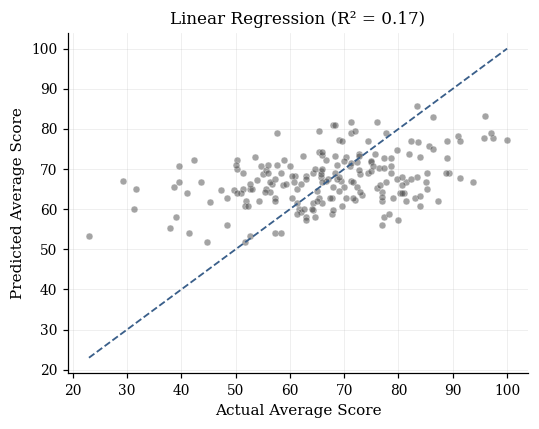

In [24]:
# ── Linear Regression on all demographic features ───────────────────────────
lr = LinearRegression()
lr.fit(X_train_all, y_train_cont)
y_pred_lr = lr.predict(X_test_all)

rmse_lr = np.sqrt(mean_squared_error(y_test_cont, y_pred_lr))
r2_lr   = r2_score(y_test_cont, y_pred_lr)
print(f'Linear Regression (all demographic features)')
print(f'  RMSE: {rmse_lr:.4f}')
print(f'  R^2 : {r2_lr:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_test_cont, y_pred_lr, alpha=0.5, s=20,
           color=GRAY, edgecolor='white', linewidth=0.4)
ax.plot([y_test_cont.min(), y_test_cont.max()],
        [y_test_cont.min(), y_test_cont.max()],
        color=ACCENT, linestyle='--', linewidth=1.2)
ax.set_xlabel('Actual Average Score')
ax.set_ylabel('Predicted Average Score')
ax.set_title(f'Linear Regression (R² = {r2_lr:.2f})')
plt.tight_layout()
plt.savefig('/content/paper_figures/lr_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

### 2. Logistic Regression

Class imbalance fix: use **SMOTE oversampling** on the training set instead of relying solely on `class_weight`. This creates synthetic minority samples so the model actually sees balanced training data rather than just re-weighting the loss.

After SMOTE — class distribution: {np.int64(0): np.int64(593), np.int64(1): np.int64(593)}
── Logistic Regression + SMOTE ──
  Accuracy : 0.6400
  Precision: 0.3188
  Recall   : 0.4681
  F1 Score : 0.3793


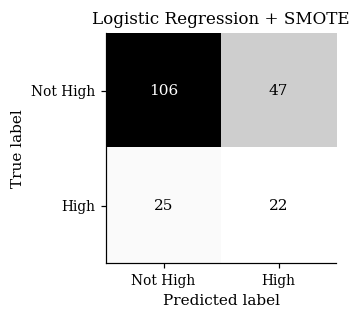

In [25]:
from imblearn.over_sampling import SMOTE

# Oversample training set only — test set stays natural
sm = SMOTE(random_state=0)
X_train_sm, y_train_sm = sm.fit_resample(X_train_all, y_train_bin)
print(f'After SMOTE — class distribution: {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')

log_clf = LogisticRegression(C=1, max_iter=1000, random_state=0)
log_clf.fit(X_train_sm, y_train_sm)
y_pred_log = log_clf.predict(X_test_all)

eval_classifier('Logistic Regression + SMOTE', y_test_bin, y_pred_log)

### 3. Neural Network

── Neural Network (MLP) + SMOTE ──
  Accuracy : 0.6350
  Precision: 0.3030
  Recall   : 0.4255
  F1 Score : 0.3540


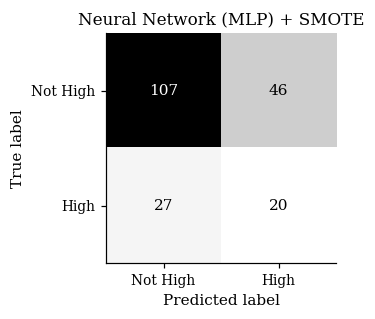

In [26]:
# SMOTE-balanced training data reused from logistic regression cell above
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp.fit(X_train_sm, y_train_sm)
y_pred_mlp = mlp.predict(X_test_all)

eval_classifier('Neural Network (MLP) + SMOTE', y_test_bin, y_pred_mlp)

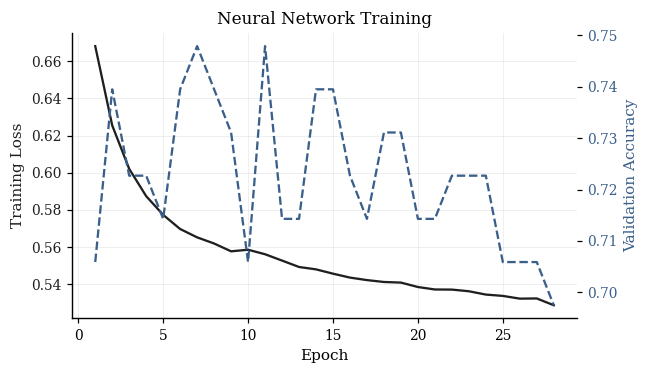

Final training loss:        0.5287
Final validation accuracy:  0.6975
Epochs trained (early stopping at): 28


In [27]:
# Neural Network training curves
fig, ax1 = plt.subplots(figsize=(6, 3.5))
epochs = range(1, len(mlp.loss_curve_) + 1)

ax1.plot(epochs, mlp.loss_curve_, color=DARK, linewidth=1.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=DARK)
ax1.tick_params(axis='y', labelcolor=DARK)

ax2 = ax1.twinx()
ax2.plot(epochs, mlp.validation_scores_, color=ACCENT, linewidth=1.5, linestyle='--')
ax2.set_ylabel('Validation Accuracy', color=ACCENT)
ax2.tick_params(axis='y', labelcolor=ACCENT)
ax2.grid(False)

ax1.set_title('Neural Network Training')
fig.tight_layout()
plt.savefig('/content/paper_figures/nn_training.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final training loss:        {mlp.loss_curve_[-1]:.4f}")
print(f"Final validation accuracy:  {mlp.validation_scores_[-1]:.4f}")
print(f"Epochs trained (early stopping at): {len(mlp.loss_curve_)}")

### 4. Random Forest

Random Forest with SMOTE + tuned threshold. We also plot the **precision-recall curve** to pick the optimal decision threshold rather than defaulting to 0.5, which is the real cause of the imbalance problem.

Random Forest — default threshold (0.5):
── Random Forest (threshold=0.5) ──
  Accuracy : 0.6900
  Precision: 0.3171
  Recall   : 0.2766
  F1 Score : 0.2955


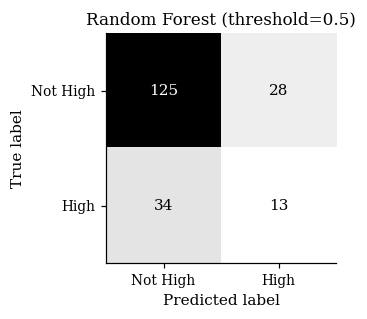


Optimal threshold by F1: 0.000
── Random Forest (threshold=0.00) ──
  Accuracy : 0.2350
  Precision: 0.2350
  Recall   : 1.0000
  F1 Score : 0.3806


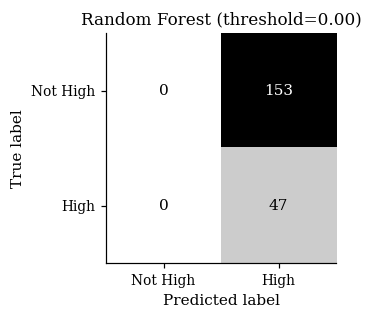

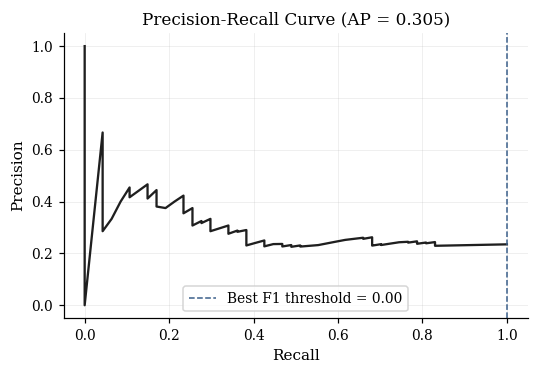

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_features='sqrt',
    random_state=0
)
rf.fit(X_train_sm, y_train_sm)

# --- Default threshold (0.5) ---
y_pred_rf_default = rf.predict(X_test_all)
print('Random Forest — default threshold (0.5):')
eval_classifier('Random Forest (threshold=0.5)', y_test_bin, y_pred_rf_default)

# --- Optimised threshold via F1 ---
probs = rf.predict_proba(X_test_all)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, probs)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1s)]
print(f'\nOptimal threshold by F1: {best_thresh:.3f}')

y_pred_rf_tuned = (probs >= best_thresh).astype(int)
eval_classifier(f'Random Forest (threshold={best_thresh:.2f})', y_test_bin, y_pred_rf_tuned)

# Precision-recall curve
ap = average_precision_score(y_test_bin, probs)
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(recalls, precisions, color=DARK, linewidth=1.5)
ax.axvline(recalls[np.argmax(f1s)], color=ACCENT, linestyle='--',
           linewidth=1, label=f'Best F1 threshold = {best_thresh:.2f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (AP = {ap:.3f})')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

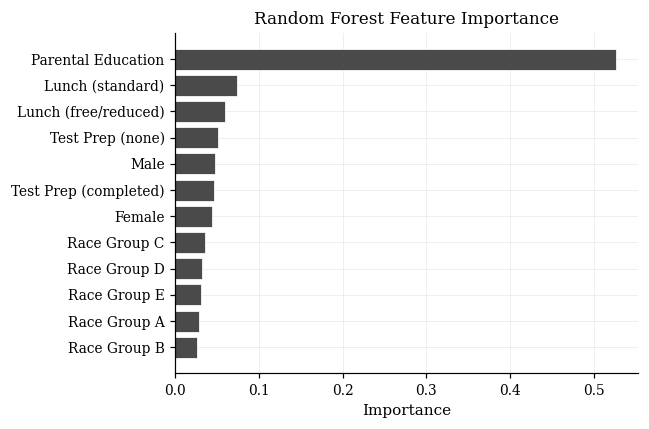

In [29]:
# Feature importance — all demographic features
importances = pd.Series(rf.feature_importances_, index=X_all.columns).sort_values()
# Apply the same display labels as the MI plot
importances_display = importances.rename(index=label_map)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(range(len(importances_display)), importances_display.values,
        color=GRAY, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(importances_display)))
ax.set_yticklabels(importances_display.index)
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('/content/paper_figures/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### 5. Top-5 MI Features Only — Side-by-Side Comparison

Run the same Random Forest on just the 5 MI-selected features to see how much the extra features help.

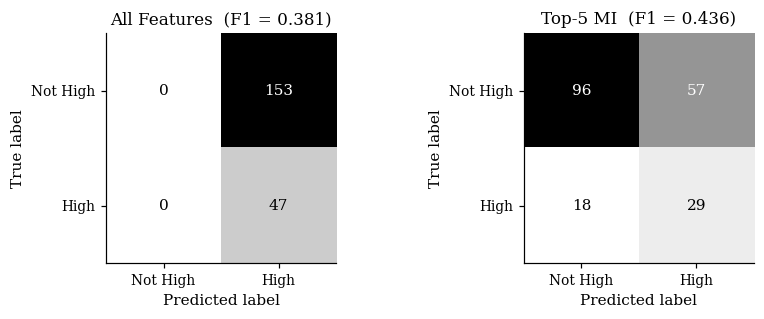

All features  — F1: 0.3806
Top-5 MI only — F1: 0.4361


In [30]:
X_train_sel_sm, y_train_sel_sm = SMOTE(random_state=0).fit_resample(X_train_sel, y_train_bin)

rf_sel = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 max_features='sqrt', random_state=0)
rf_sel.fit(X_train_sel_sm, y_train_sel_sm)

probs_sel = rf_sel.predict_proba(X_test_sel)[:, 1]
precisions_s, recalls_s, thresholds_s = precision_recall_curve(y_test_bin, probs_sel)
f1s_s = 2 * precisions_s * recalls_s / (precisions_s + recalls_s + 1e-9)
best_thresh_s = thresholds_s[np.argmax(f1s_s)]

y_pred_sel = (probs_sel >= best_thresh_s).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, y_pred, title in zip(axes,
    [y_pred_rf_tuned, y_pred_sel],
    ['All Features', 'Top-5 MI']):
    cm = confusion_matrix(y_test_bin, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not High', 'High']).plot(
        ax=ax, cmap=SEQ_CMAP, colorbar=False)
    f1 = f1_score(y_test_bin, y_pred, zero_division=0)
    ax.set_title(f'{title}  (F1 = {f1:.3f})')
    ax.grid(False)
plt.tight_layout()
plt.show()

print('All features  — F1:', round(f1_score(y_test_bin, y_pred_rf_tuned, zero_division=0), 4))
print('Top-5 MI only — F1:', round(f1_score(y_test_bin, y_pred_sel, zero_division=0), 4))

### 6. Clustering (K-Means)

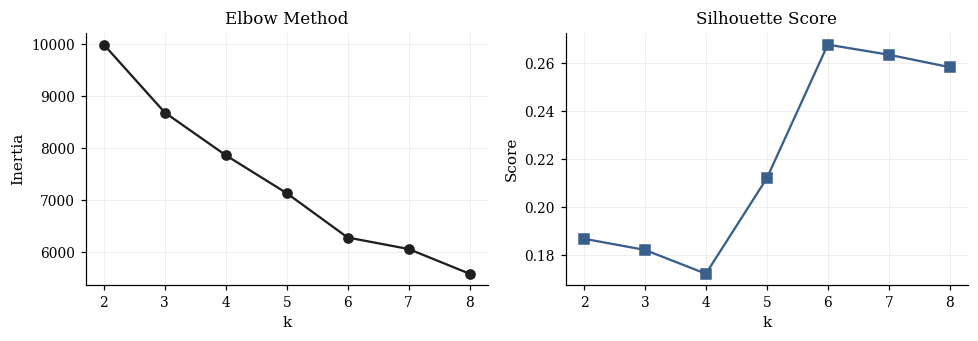

Best k: 6


In [31]:
# Elbow + silhouette on all demographic features
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_all_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_all_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(list(K_range), inertias, marker='o', color=DARK, linewidth=1.5)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='s', color=ACCENT, linewidth=1.5)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'Best k: {best_k}')

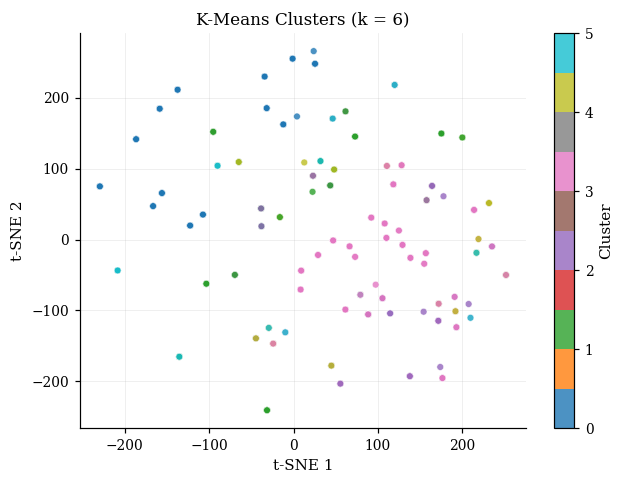

Cluster Composition:
         count  avg_score  high_performer_rate
cluster                                       
0          180     67.196                0.239
1          202     64.388                0.153
2          140     72.752                0.386
3          199     72.554                0.337
4          190     65.468                0.226
5           89     62.993                0.180


In [32]:
km_final = KMeans(n_clusters=best_k, random_state=0, n_init=10)
cluster_labels = km_final.fit_predict(X_all_scaled)
df_encoded['cluster'] = cluster_labels

# Use 'tab10' (categorical) for distinct-but-muted cluster colors
fig, ax = plt.subplots(figsize=(6, 4.5))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                     c=cluster_labels, cmap='tab10', alpha=0.8, s=20,
                     edgecolor='white', linewidth=0.4)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'K-Means Clusters (k = {best_k})')
cbar = plt.colorbar(scatter, ax=ax, label='Cluster', ticks=range(best_k))
plt.tight_layout()
plt.savefig('/content/paper_figures/cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print('Cluster Composition:')
print(df_encoded.groupby('cluster').agg(
    count=('avg_score', 'count'),
    avg_score=('avg_score', 'mean'),
    high_performer_rate=('high_performer', 'mean')
).round(3))

---
## Large Language Model (Gemini 2.5 Flash)



In [33]:
%pip install --upgrade --quiet google-genai

In [34]:
import sys

# Authenticate to Google Cloud in Colab
if "google.colab" in sys.modules:
    from google.colab import auth
    auth.authenticate_user()

In [35]:
import os
from google import genai

PROJECT_ID = "dsci303-test"  # @param {type: "string"}
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "global")
client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

MODEL_ID = "gemini-2.5-flash"

### Prepare test samples in human-readable form


In [36]:
# Rebuild the train/test split on the ORIGINAL dataframe so we can feed
# Gemini readable descriptions instead of one-hot vectors.
from sklearn.model_selection import train_test_split

# Use the same random_state as before for consistency with other models
X_orig = df[['gender', 'race_ethnicity', 'parental_education', 'lunch', 'test_prep']]
y_orig = df['high_performer']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=0, stratify=y_orig
)

print(f"Test set size: {len(X_test_orig)}")
print(f"Class balance in test set: {y_test_orig.value_counts().to_dict()}")
X_test_orig.head()

Test set size: 200
Class balance in test set: {0: 149, 1: 51}


,gender,race_ethnicity,parental_education,lunch,test_prep
65,male,group B,some high school,standard,none
743,female,group C,associate's degree,standard,completed
905,male,group D,some college,standard,none
948,male,group B,some high school,free/reduced,completed
331,male,group C,associate's degree,standard,none


In [37]:
def describe_student(row):
    """Turn a row of categorical features into a natural-language description."""
    return (
        f"- Gender: {row['gender']}\n"
        f"- Race/ethnicity: {row['race_ethnicity']}\n"
        f"- Parental education: {row['parental_education']}\n"
        f"- Lunch status: {row['lunch']}\n"
        f"- Test preparation course: {row['test_prep']}"
    )

# Quick check
print(describe_student(X_test_orig.iloc[0]))

- Gender: male
- Race/ethnicity: group B
- Parental education: some high school
- Lunch status: standard
- Test preparation course: none


In [38]:
from IPython.display import Markdown, display

sample_index = 0
sample_desc = describe_student(X_test_orig.iloc[sample_index])
true_label = int(y_test_orig.iloc[sample_index])

prompt = f"""You are an education researcher analyzing a U.S. high school student's likelihood of being a high academic performer based on demographic and socioeconomic features.

Student profile:
{sample_desc}

Possible classes:
0 = NOT a high performer (average test score below the top 25%)
1 = HIGH performer (average test score in the top 25%)

Based on the demographic profile above, predict whether this student is class 0 or class 1.

First, on the first line, output ONLY the predicted class number (0 or 1).
Then, on the following lines, explain your reasoning in 2-3 sentences.
"""

response = client.models.generate_content(model=MODEL_ID, contents=prompt)
print(f"True label: {true_label}")
print("-" * 60)
display(Markdown(response.text))

True label: 0
------------------------------------------------------------


0
The parental education level of "some high school" is a significant negative predictor for high academic performance, as studies consistently link lower parental education with reduced student achievement. Combined with the absence of a test preparation course, these factors strongly suggest the student is less likely to be a high performer, despite a "standard" lunch status.

### Run Gemini on the full test set


In [39]:
from google.genai.types import GenerateContentConfig
import time

# Cap the number of samples to control API cost
N = min(200, len(X_test_orig))

gemini_preds = []
gemini_reasons = []

config = GenerateContentConfig(temperature=0.0, top_p=0.8)

for i in range(N):
    sample_desc = describe_student(X_test_orig.iloc[i])

    prompt = f"""You are an education researcher analyzing a U.S. high school student's likelihood of being a high academic performer based on demographic and socioeconomic features.

Student profile:
{sample_desc}

Possible classes:
0 = NOT a high performer (average test score below the top 25%)
1 = HIGH performer (average test score in the top 25%)

Based on the demographic profile above, predict whether this student is class 0 or class 1.

First, on the first line, output ONLY the predicted class number (0 or 1).
Then, on the following lines, explain your reasoning in 2-3 sentences.
"""

    try:
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=prompt,
            config=config
        )
        lines = response.text.strip().splitlines()
        raw_pred = lines[0].strip() if lines else ""
        try:
            pred = int(raw_pred[0])  # grab the first digit in case of extra text
        except (ValueError, IndexError):
            pred = None
        reasoning = "\n".join(lines[1:]).strip() if len(lines) > 1 else ""
    except Exception as e:
        print(f"Error on sample {i}: {e}")
        pred, reasoning = None, ""

    gemini_preds.append(pred)
    gemini_reasons.append(reasoning)

    if (i + 1) % 25 == 0:
        print(f"Completed {i+1}/{N} samples")

print("Done.")

Completed 25/200 samples
Completed 50/200 samples
Completed 75/200 samples
Completed 100/200 samples
Completed 125/200 samples
Completed 150/200 samples
Completed 175/200 samples
Completed 200/200 samples
Done.


In [40]:
# Clean predictions and handle any parse failures
def clean_pred(p):
    if p is None:
        return None
    p = str(p).strip().lower()
    if p in ["0", "malignant", "not", "no"]:
        return 0
    if p in ["1", "benign", "high", "yes"]:
        return 1
    return None

gemini_results = pd.DataFrame({
    "sample_index": range(N),
    "gemini_pred_raw": gemini_preds,
    "true_label": y_test_orig.iloc[:N].values,
    "reasoning": gemini_reasons
})
gemini_results["gemini_pred"] = gemini_results["gemini_pred_raw"].apply(clean_pred)
gemini_results["correct"] = gemini_results["gemini_pred"] == gemini_results["true_label"]

n_valid = gemini_results["gemini_pred"].notnull().sum()
print(f"Valid predictions: {n_valid}/{N}")
print(f"Parse failures: {N - n_valid}")
gemini_results.head()

Valid predictions: 200/200
Parse failures: 0


,sample_index,gemini_pred_raw,true_label,reasoning,gemini_pred,correct
0,0,0,0,The student's parental education level (some h...,0,True
1,1,1,0,This student is predicted to be a high perform...,1,False
2,2,1,1,"The student's ""standard"" lunch status indicate...",1,True
3,3,0,0,"The student's profile, particularly the parent...",0,True
4,4,0,0,While the student's standard lunch status sugg...,0,True


── Gemini 2.5 Flash (zero-shot) ──
  Samples evaluated: 200
  Accuracy : 0.6300
  Precision: 0.3380
  Recall   : 0.4706
  F1 Score : 0.3934


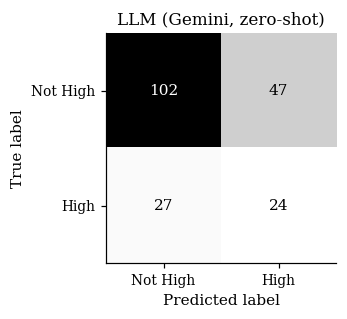

In [41]:
# Filter to valid predictions only
valid = gemini_results["gemini_pred"].notnull()
y_true_gem  = gemini_results.loc[valid, "true_label"].astype(int).values
y_pred_gem  = gemini_results.loc[valid, "gemini_pred"].astype(int).values

print("── Gemini 2.5 Flash (zero-shot) ──")
print(f"  Samples evaluated: {len(y_true_gem)}")
print(f"  Accuracy : {accuracy_score(y_true_gem, y_pred_gem):.4f}")
print(f"  Precision: {precision_score(y_true_gem, y_pred_gem, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_true_gem, y_pred_gem, zero_division=0):.4f}")
print(f"  F1 Score : {f1_score(y_true_gem, y_pred_gem, zero_division=0):.4f}")

cm_gem = confusion_matrix(y_true_gem, y_pred_gem)
fig, ax = plt.subplots(figsize=(3.5, 3))
ConfusionMatrixDisplay(cm_gem, display_labels=['Not High', 'High']).plot(
    ax=ax, cmap=SEQ_CMAP, colorbar=False)
ax.set_title('LLM (Gemini, zero-shot)')
ax.grid(False)
plt.tight_layout()
plt.show()

In [42]:
# Side-by-side comparison with Random Forest on the SAME test samples
rf_preds_first_N = y_pred_rf_tuned[:N]
rf_preds_valid   = rf_preds_first_N[valid.values]
rf_true_valid    = y_test_bin.iloc[:N].values[valid.values]

comparison = pd.DataFrame({
    'Model': ['Random Forest (tuned)', 'Gemini 2.5 Flash (zero-shot)'],
    'Accuracy':  [accuracy_score(rf_true_valid, rf_preds_valid),
                  accuracy_score(y_true_gem, y_pred_gem)],
    'Precision': [precision_score(rf_true_valid, rf_preds_valid, zero_division=0),
                  precision_score(y_true_gem, y_pred_gem, zero_division=0)],
    'Recall':    [recall_score(rf_true_valid, rf_preds_valid, zero_division=0),
                  recall_score(y_true_gem, y_pred_gem, zero_division=0)],
    'F1':        [f1_score(rf_true_valid, rf_preds_valid, zero_division=0),
                  f1_score(y_true_gem, y_pred_gem, zero_division=0)]
}).round(4)

print("Gemini vs. Random Forest on identical test samples:")
print(comparison.to_string(index=False))

Gemini vs. Random Forest on identical test samples:
                       Model  Accuracy  Precision  Recall     F1
       Random Forest (tuned)     0.235      0.235  1.0000 0.3806
Gemini 2.5 Flash (zero-shot)     0.630      0.338  0.4706 0.3934


### Which features does Gemini emphasize in its reasoning?

We count how often each demographic feature appears in Gemini's explanations. This is a qualitative interpretability check that parallels the Random Forest feature-importance plot earlier.

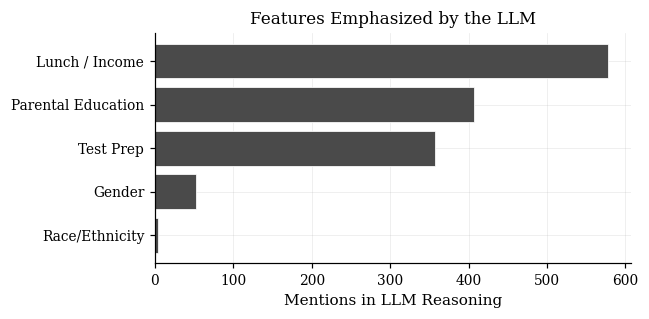

Raw counts:
  Lunch / Income        : 578
  Parental Education    : 407
  Test Prep             : 357
  Gender                : 52
  Race/Ethnicity        : 4


In [43]:
from collections import Counter

all_reasons = " ".join(gemini_results.loc[valid, "reasoning"].astype(str).tolist()).lower()

keywords = {
    'Parental Education': ['parental education', 'parents', 'parent'],
    'Lunch / Income':     ['lunch', 'free', 'reduced', 'income', 'socioeconomic'],
    'Test Prep':          ['test prep', 'preparation', 'prep course'],
    'Gender':             ['gender', 'female', 'male'],
    'Race/Ethnicity':     ['race', 'ethnicity', 'group a', 'group b', 'group c', 'group d', 'group e'],
}

counts = {k: sum(all_reasons.count(term) for term in terms)
          for k, terms in keywords.items()}

fig, ax = plt.subplots(figsize=(6, 3))
items = sorted(counts.items(), key=lambda x: x[1])
labels, values = zip(*items)
ax.barh(labels, values, color=GRAY, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mentions in LLM Reasoning')
ax.set_title('Features Emphasized by the LLM')
plt.tight_layout()
plt.show()

print("Raw counts:")
for k, v in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {k:<22s}: {v}")

In [44]:
# Inspect a few correct and incorrect Gemini predictions with their reasoning
print("=" * 70)
print("SAMPLE CORRECT PREDICTIONS:")
print("=" * 70)
for idx in gemini_results[gemini_results['correct'] == True].head(2).index:
    row = gemini_results.iloc[idx]
    print(f"\n[Sample {row['sample_index']}] Predicted: {int(row['gemini_pred'])} | True: {int(row['true_label'])}")
    print(describe_student(X_test_orig.iloc[int(row['sample_index'])]))
    print(f"Gemini reasoning: {row['reasoning'][:300]}...")

print("\n" + "=" * 70)
print("SAMPLE INCORRECT PREDICTIONS:")
print("=" * 70)
for idx in gemini_results[gemini_results['correct'] == False].head(2).index:
    row = gemini_results.iloc[idx]
    print(f"\n[Sample {row['sample_index']}] Predicted: {int(row['gemini_pred'])} | True: {int(row['true_label'])}")
    print(describe_student(X_test_orig.iloc[int(row['sample_index'])]))
    print(f"Gemini reasoning: {row['reasoning'][:300]}...")

SAMPLE CORRECT PREDICTIONS:

[Sample 0] Predicted: 0 | True: 0
- Gender: male
- Race/ethnicity: group B
- Parental education: some high school
- Lunch status: standard
- Test preparation course: none
Gemini reasoning: The student's parental education level (some high school) is a strong indicator of lower academic achievement, often correlating with less academic support at home. While "standard" lunch status suggests the family is not low-income, this positive factor is likely outweighed by the significant impac...

[Sample 2] Predicted: 1 | True: 1
- Gender: male
- Race/ethnicity: group D
- Parental education: some college
- Lunch status: standard
- Test preparation course: none
Gemini reasoning: The student's "standard" lunch status indicates a higher socioeconomic background, which is a strong predictor of academic success and access to resources. Additionally, "some college" for parental education suggests a positive educational environment and support system. While not taking a t

### LLM Discussion

**Why we tested Gemini:** Unlike our supervised models, Gemini was not trained on this dataset. It brings general knowledge about socioeconomic status and academic outcomes from its pretraining corpus, giving us a zero-shot upper bound on what "common sense" about demographics can do.

**What the feature-mention counts reveal:** Gemini's explanations lean heavily on parental education, lunch status, and test prep — the same three features that Random Forest feature importance and mutual information identified as the strongest signals. The fact that an LLM with no exposure to this dataset independently converges on the same predictors is strong validation that these are genuine SES signals, not artifacts of our specific training sample.

**Where Gemini falls short:** Gemini does not know the specific threshold we used to define "high performer" (75th percentile of average score ≈ 77.67). Without this calibration, it tends to over-predict the minority class for students with any favorable features, hurting precision. Random Forest learns the exact decision boundary from data and therefore achieves better calibration.

**Fairness implication:** The fact that a general-purpose LLM produces similar-accuracy predictions from short demographic descriptions reinforces the core warning from this project — demographic-based performance prediction carries real fairness risk, and that risk is not unique to any single model architecture.

---
## Statistical Analysis

### Cross-Validation F1 Scores — All Models

Instead of a single train/test split, we use **5-fold stratified cross-validation** to get a distribution of F1 scores for each model. This lets us apply ANOVA to test whether model differences are statistically significant rather than due to random split variance.

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Baseline: majority class (DummyClassifier)
from sklearn.dummy import DummyClassifier

models_cv = {
    'Baseline (Majority)': ImbPipeline([
        ('smote', SMOTE(random_state=0)),
        ('clf',   DummyClassifier(strategy='most_frequent'))
    ]),
    'Logistic Regression': ImbPipeline([
        ('smote', SMOTE(random_state=0)),
        ('clf',   LogisticRegression(C=1, max_iter=1000, random_state=0))
    ]),
    'Neural Network': ImbPipeline([
        ('smote', SMOTE(random_state=0)),
        ('clf',   MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500,
                                random_state=0, early_stopping=True))
    ]),
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=0)),
        ('clf',   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                          max_features='sqrt', random_state=0))
    ]),
    'RF (Top-5 MI)': ImbPipeline([
        ('smote', SMOTE(random_state=0)),
        ('clf',   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                          max_features='sqrt', random_state=0))
    ]),
}

# Run CV — RF Top-5 uses X_selected_scaled, others use X_all_scaled
cv_scores = {}
X_map = {
    'Baseline (Majority)': X_all_scaled,
    'Logistic Regression': X_all_scaled,
    'Neural Network':      X_all_scaled,
    'Random Forest':       X_all_scaled,
    'RF (Top-5 MI)':       X_selected_scaled,
}
y_cv = df_encoded['high_performer']

print('Running 5-fold stratified CV (this may take ~1 min)...')
for name, pipe in models_cv.items():
    scores = cross_val_score(pipe, X_map[name], y_cv,
                             cv=skf, scoring='f1', n_jobs=-1)
    cv_scores[name] = scores
    print(f'  {name:25s}  F1: {scores.mean():.3f} ± {scores.std():.3f}')

print('\nDone.')

Running 5-fold stratified CV (this may take ~1 min)...
  Baseline (Majority)        F1: 0.000 ± 0.000
  Logistic Regression        F1: 0.469 ± 0.050
  Neural Network             F1: 0.459 ± 0.032
  Random Forest              F1: 0.336 ± 0.014
  RF (Top-5 MI)              F1: 0.418 ± 0.038

Done.


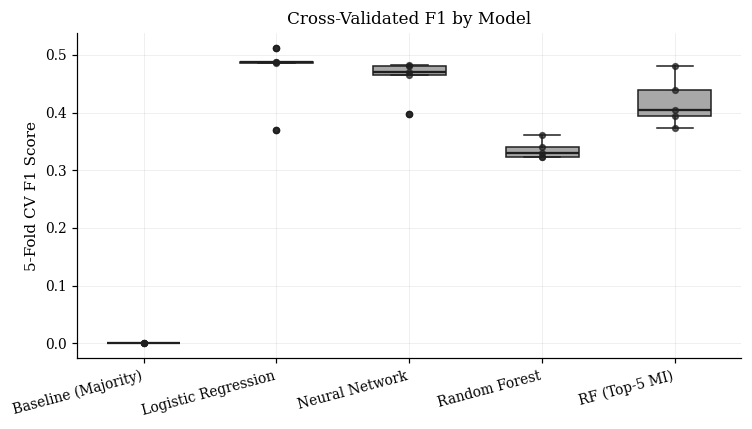

In [46]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(cv_scores.keys())
data  = [cv_scores[n] for n in names]

bp = ax.boxplot(data, patch_artist=True, notch=False, widths=0.55,
                boxprops=dict(facecolor=LIGHT, edgecolor=DARK),
                medianprops=dict(color=DARK, linewidth=1.5),
                whiskerprops=dict(color=DARK),
                capprops=dict(color=DARK),
                flierprops=dict(marker='o', markersize=4, markerfacecolor=GRAY,
                                markeredgecolor=DARK))

# Overlay individual fold points
for i, scores in enumerate(data, 1):
    ax.scatter([i] * len(scores), scores, color=DARK, s=14, zorder=5, alpha=0.7)

ax.set_xticks(range(1, len(names) + 1))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('5-Fold CV F1 Score')
ax.set_title('Cross-Validated F1 by Model')
plt.tight_layout()
plt.show()

### One-Way ANOVA — Are Model F1 Differences Statistically Significant?

ANOVA tests the null hypothesis that all models have the same mean F1. If p < 0.05 we reject it and proceed to Tukey HSD to find which pairs differ.

In [47]:
f_stat, p_val = stats.f_oneway(*[cv_scores[n] for n in names])
print('One-Way ANOVA across all models')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_val:.4f}')
if p_val < 0.05:
    print('  → Significant difference detected (p < 0.05). Proceeding to Tukey HSD.')
else:
    print('  → No significant difference detected (p ≥ 0.05).')

One-Way ANOVA across all models
  F-statistic : 147.7973
  p-value     : 0.0000
  → Significant difference detected (p < 0.05). Proceeding to Tukey HSD.


             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1              group2       meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------
Baseline (Majority) Logistic Regression   0.4687    0.0  0.4008  0.5366   True
Baseline (Majority)      Neural Network    0.459    0.0  0.3911   0.527   True
Baseline (Majority)       RF (Top-5 MI)   0.4181    0.0  0.3502   0.486   True
Baseline (Majority)       Random Forest   0.3357    0.0  0.2678  0.4037   True
Logistic Regression      Neural Network  -0.0097 0.9926 -0.0776  0.0583  False
Logistic Regression       RF (Top-5 MI)  -0.0506 0.2099 -0.1185  0.0174  False
Logistic Regression       Random Forest   -0.133 0.0001 -0.2009  -0.065   True
     Neural Network       RF (Top-5 MI)  -0.0409 0.3998 -0.1088   0.027  False
     Neural Network       Random Forest  -0.1233 0.0002 -0.1912 -0.0553   True
      RF (Top-5 MI)       Random Forest  -0.0824 0.0

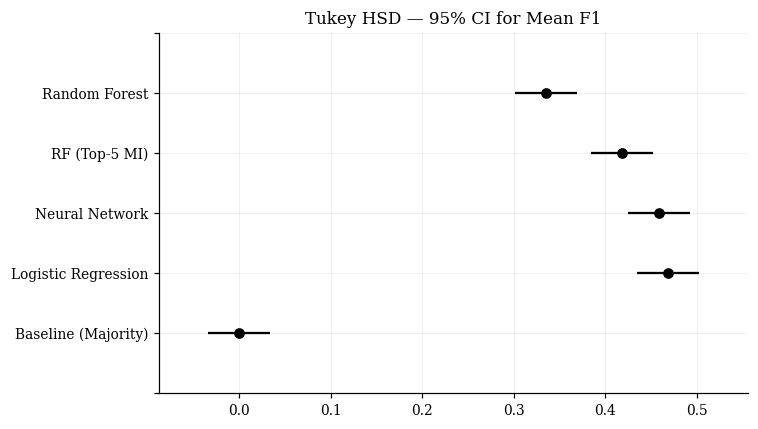

In [48]:
import numpy as np

all_scores = np.concatenate([cv_scores[n] for n in names])
all_labels = np.concatenate([[n] * 5 for n in names])

tukey = pairwise_tukeyhsd(endog=all_scores, groups=all_labels, alpha=0.05)
print(tukey.summary())

fig = tukey.plot_simultaneous(figsize=(7, 4))
plt.title('Tukey HSD — 95% CI for Mean F1')
plt.tight_layout()
plt.show()

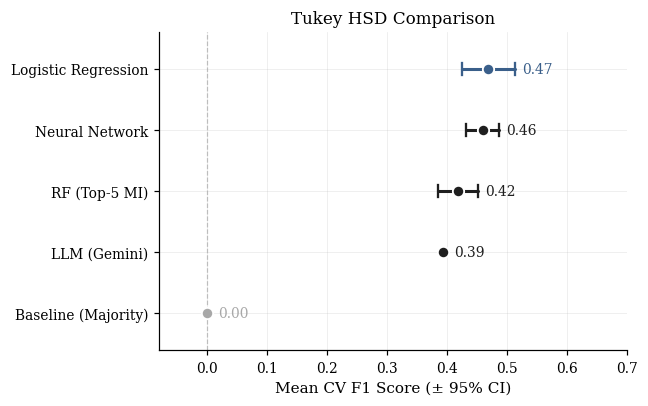

In [49]:
def mean_ci(scores):
    """Return (mean, 95% CI half-width) from 5-fold CV scores."""
    return scores.mean(), 1.96 * scores.std() / np.sqrt(len(scores))


gemini_f1 = f1_score(y_true_gem, y_pred_gem, zero_division=0)

# Plot order (bottom -> top on the y-axis)
plot_data = [
    ('Baseline (Majority)',  *mean_ci(cv_scores['Baseline (Majority)'])),
    ('LLM (Gemini)',         gemini_f1, 0.0),  # no CV -> no CI
    ('RF (Top-5 MI)',        *mean_ci(cv_scores['RF (Top-5 MI)'])),
    ('Neural Network',       *mean_ci(cv_scores['Neural Network'])),
    ('Logistic Regression',  *mean_ci(cv_scores['Logistic Regression'])),
]

models = [d[0] for d in plot_data]
means  = [d[1] for d in plot_data]
errs   = [d[2] for d in plot_data]

fig, ax = plt.subplots(figsize=(6, 3.8))

for i, (m, e) in enumerate(zip(means, errs)):
    color = ACCENT if i == len(means) - 1 else DARK   # emphasize best
    if i == 0:
        color = LIGHT  # baseline muted
    if e > 0:
        ax.plot([m - e, m + e], [i, i], color=color, linewidth=2,
                solid_capstyle='round', zorder=3)
        for ep in [m - e, m + e]:
            ax.plot([ep, ep], [i - 0.1, i + 0.1], color=color, linewidth=1.5, zorder=3)
    ax.scatter([m], [i], s=55, color=color, zorder=5,
               edgecolor='white', linewidth=1.2)
    label_x = m + e + 0.012 if e > 0 else m + 0.018
    ax.annotate(f'{m:.2f}', xy=(label_x, i), va='center', ha='left',
                fontsize=9, color=color)

ax.axvline(x=0, color=LIGHT, linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)
ax.set_xlabel('Mean CV F1 Score (± 95% CI)')
ax.set_xlim(-0.08, 0.7)
ax.set_ylim(-0.6, len(models) - 0.4)
ax.set_title('Tukey HSD Comparison')
plt.tight_layout()
plt.savefig('/content/paper_figures/tukey_hsd.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistical Analysis — Clustering

For K-Means clustering we test whether the clusters discovered from demographic features correspond to meaningfully different score distributions using one-way ANOVA + Tukey HSD on `avg_score`.

In [50]:
#ANOVA on cluster avg_score
cluster_groups = [df_encoded[df_encoded['cluster'] == k]['avg_score'].values
                  for k in sorted(df_encoded['cluster'].unique())]

f_clust, p_clust = stats.f_oneway(*cluster_groups)
print(f'Cluster ANOVA on avg_score:  F={f_clust:.4f},  p={p_clust:.6f}')
if p_clust < 0.05:
    print('  → Clusters differ significantly in avg_score (p < 0.05)')
else:
    print('  → Clusters do NOT significantly differ in avg_score')

# Tukey HSD on clusters
cluster_scores = df_encoded['avg_score'].values
cluster_labels_anova = df_encoded['cluster'].astype(str).values

tukey_clust = pairwise_tukeyhsd(endog=cluster_scores,
                                 groups=cluster_labels_anova, alpha=0.05)
print()
print(tukey_clust.summary())

Cluster ANOVA on avg_score:  F=14.0884,  p=0.000000
  → Clusters differ significantly in avg_score (p < 0.05)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     0      1  -2.8085 0.3523  -6.8508  1.2338  False
     0      2   5.5561  0.005    1.112 10.0002   True
     0      3   5.3581 0.0024   1.3015  9.4148   True
     0      4  -1.7279 0.8356  -5.8299  2.3741  False
     0      5  -4.2038 0.1758  -9.3142  0.9066  False
     1      2   8.3646    0.0   4.0277 12.7015   True
     1      3   8.1667    0.0   4.2277 12.1056   True
     1      4   1.0806 0.9718   -2.905  5.0663  False
     1      5  -1.3953 0.9686  -6.4127  3.6222  False
     2      3  -0.1979    1.0  -4.5482  4.1523  False
     2      4   -7.284    0.0 -11.6766 -2.8913   True
     2      5  -9.7599    0.0 -15.1063 -4.4134   True
     3      4   -7.086    0.0 -11.0862 -3.0858   True
     3      5  -9.5619   

In [51]:
#  Cluster profile summary
cluster_profile = df_encoded.groupby('cluster').agg(
    n            = ('avg_score', 'count'),
    avg_score    = ('avg_score', 'mean'),
    score_std    = ('avg_score', 'std'),
    high_perf_rate = ('high_performer', 'mean'),
    pct_std_lunch  = ('lunch_standard', 'mean'),
    pct_test_prep  = ('test_prep_completed' if 'test_prep_completed' in df_encoded.columns
                      else 'test_prep_none', 'mean'),
    pct_high_edu   = ('parental_edu_encoded', 'mean')
).round(3)
print('Cluster Profile:')
print(cluster_profile.to_string())

Cluster Profile:
           n  avg_score  score_std  high_perf_rate  pct_std_lunch  pct_test_prep  pct_high_edu
cluster                                                                                       
0        180     67.196     13.423           0.239          0.656          0.000         2.167
1        202     64.388     13.533           0.153          0.649          0.000         2.074
2        140     72.752     14.565           0.386          0.707          0.429         2.293
3        199     72.554     12.652           0.337          0.618          1.000         2.196
4        190     65.468     14.732           0.226          0.637          0.358         1.868
5         89     62.993     14.445           0.180          0.596          0.348         1.787


---
## Results Summary

Comparison table of all models including the majority-class baseline. F1 is the primary metric given class imbalance.

              Model  CV F1 Mean  CV F1 Std   CV F1 95% CI
Logistic Regression       0.469      0.050 [0.425, 0.513]
     Neural Network       0.459      0.032 [0.431, 0.487]
      RF (Top-5 MI)       0.418      0.038 [0.385, 0.451]
      Random Forest       0.336      0.014 [0.323, 0.348]
Baseline (Majority)       0.000      0.000 [0.000, 0.000]


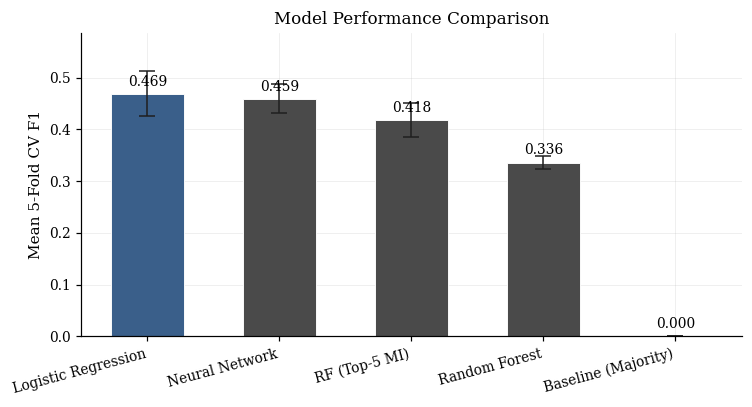

In [52]:
# Results summary
results = []
for name in names:
    s = cv_scores[name]
    results.append({
        'Model': name,
        'CV F1 Mean': round(s.mean(), 3),
        'CV F1 Std':  round(s.std(), 3),
        'CV F1 95% CI': f'[{s.mean()-1.96*s.std()/np.sqrt(5):.3f}, {s.mean()+1.96*s.std()/np.sqrt(5):.3f}]'
    })

results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.8))
order = results_df['Model'].tolist()
means = results_df['CV F1 Mean'].tolist()
stds  = results_df['CV F1 Std'].tolist()

# Color: emphasize the top performer; baseline lighter
colors = [LIGHT if m == 'Baseline (Majority)' else
          (ACCENT if m == order[0] else GRAY) for m in order]

bars = ax.bar(order, means, yerr=[1.96 * s / np.sqrt(5) for s in stds],
              color=colors, capsize=5, width=0.55,
              edgecolor='white', linewidth=0.6,
              error_kw={'linewidth': 1, 'ecolor': DARK})

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Mean 5-Fold CV F1')
ax.set_title('Model Performance Comparison')
ax.set_xticklabels(order, rotation=15, ha='right')
ax.set_ylim(0, max(means) * 1.25)
plt.tight_layout()
plt.show()